# Search the Alert Stream for Possible Unmatched SSOs

Author: James E. Robinson

This notebook gives a rough starting point for working with LSST alerts through the Fink broker.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import astropy.units as u
from astropy.time import Time
import io
import requests
from PIL import Image as im
from astropy.io import fits
from astropy.wcs import WCS
import glob
from reproject.mosaicking import find_optimal_celestial_wcs
from reproject import reproject_exact,reproject_interp,reproject_adaptive
from reproject.mosaicking import reproject_and_coadd
from astropy.visualization.wcsaxes import WCSAxes
from astropy import visualization as aviz

## Fink Data Transfer

Use the Fink Data Transfer service to query and filter alerts of interest: https://lsst.fink-portal.org/download

Documentation: https://doc.lsst.fink-broker.org/services/data_transfer/

Install and register with `fink-client`: https://github.com/astrolabsoftware/fink-client

Use the interface to build the query or load a previous query from a .yml. For this notebook we are interested in in exploring the alert stream for unidentified fast moving objects. The main components of this query are alerts with:
- not identified as a moving object (no `ssObjectId`)
- fast moving (`trailLength` > 2 arcsec)
- return only selected fields from the `DiaSource` table (minimise size of requested data)
The data transfer interface will set up a kafka stream and provide a `fink-client` command to run on your local machine to download the requested data.

In [2]:
# read the data from the query as a pandas DataFrame
df_dia = pd.read_parquet("ftransfer_lsst_2026-08-06_682423")

In [3]:
df_dia

,diaSourceId,midpointMjdTai,ra,dec,trailFlux,trailLength,trailFluxErr,trailAngle,trailAngleErr,raErr,decErr,trailLengthErr,visit,detector,band
0,313998538313302074,61057.167309,52.065190,-29.449121,1976.674438,2.296702,9.053102,-68.560486,NaN,0.000084,0.000097,NaN,2026011600057,5,i
1,313998539118608490,61057.174238,61.560875,-49.986902,1459.955444,3.141983,37.175476,-49.748508,NaN,0.000025,0.000024,NaN,2026011600063,5,g
2,313998538337419291,61057.167309,52.769543,-28.762112,1883.833252,2.349028,45.966278,14.755358,NaN,0.000047,0.000050,NaN,2026011600057,51,i
3,313998538326933734,61057.167309,53.495765,-29.790365,2043.465088,2.079923,29.364237,-110.036674,NaN,0.000051,0.000045,NaN,2026011600057,31,i
4,313998538386178085,61057.167309,53.107212,-27.552296,2045.266235,2.728169,33.669872,-95.889389,NaN,0.000050,0.000047,NaN,2026011600057,144,i
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620476,313985344712212623,61054.139665,148.787438,2.755186,4079.244873,3.197858,73.880264,-30.439663,NaN,0.000056,0.000055,NaN,2026011300061,8,u
620477,313985344730562574,61054.139665,149.027415,2.044501,2342.515869,2.193122,13.458587,-19.398203,NaN,0.000130,0.000131,NaN,2026011300061,43,u
620478,313985344758874140,61054.139665,150.048289,2.044627,3112.042480,2.875813,10.987961,36.435528,NaN,0.000103,0.000105,NaN,2026011300061,97,u
620479,313985344779321372,61054.139665,150.341712,1.900886,2980.604736,2.970550,45.589653,-3.486547,NaN,0.000037,0.000037,NaN,2026011300061,136,u


In [4]:
# LSST provides fluxes (not magnitudes) for diaSources because difference imaging can result in negative flux detections
# Calculate magnitude and uncertainties from the selected flux measurement (NB log10 warning)
# We have queried for trailFlux which is a psf fit convolved with linear motion; psfFlux, apFlux etc are also available
# See schema: https://sdm-schemas.lsst.io/apdb.html
# See Data Products Definition Document: https://lse-163.lsst.io/

col = "trail"
colFlux = col+"Flux"
colMag = col+"Mag"
colFluxErr = colFlux+"Err"
colMagErr = colMag+"Err"

df_dia[colMag] = (np.array(df_dia[colFlux])*u.nJy).to(u.ABmag).value
df_dia[colMagErr] = np.abs((2.5 / np.log(10)) * (np.array(df_dia[colFluxErr]) / np.array(df_dia[colFlux])))

/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/lib/python3.13/site-packages/astropy/units/function/logarithmic.py:67: RuntimeWarning: invalid value encountered in log10
  return dex.to(self._function_unit, np.log10(x))


In [5]:
# check the time range covered by the alerts we have retrieved
print(Time(np.amin(df_dia["midpointMjdTai"]), format = "mjd", scale = "tai").utc.iso)
print(Time(np.amax(df_dia["midpointMjdTai"]), format = "mjd", scale = "tai").utc.iso)

2026-01-01 05:16:21.895
2026-07-14 10:03:00.470


In [6]:
# NB the pipeline does not alert on sources moving > 10 deg/day; secret spy satellites :O
motion_limit = (10 * u.deg / u.day).to(u.arcsec/u.s).value * 30.

620481


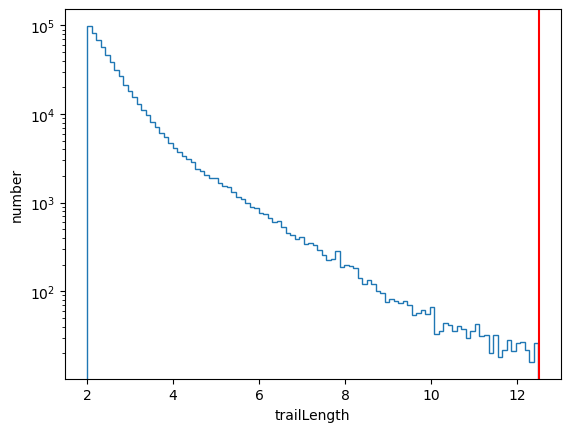

In [7]:
# histogram of retrieved trailLength
x_plot = "trailLength"
df_plot = df_dia
print(len(df_plot))

fig = plt.figure()
gs = gridspec.GridSpec(1, 1)
ax1 = plt.subplot(gs[0,0])

ax1.hist(df_plot[x_plot], bins = 100, histtype = "step")

ax1.set_xlabel(x_plot)
ax1.set_ylabel("number")
ax1.set_yscale("log")

ax1.axvline(motion_limit, c = "r", label = "pipeline cut-off")

plt.show()

620481


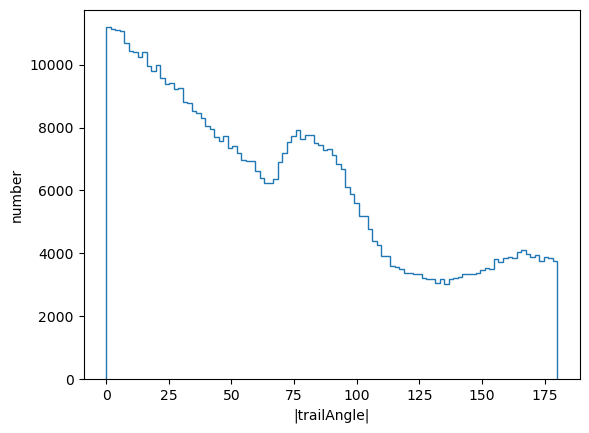

In [8]:
# histogram of measured trailAngle
# compare abs(trailAngle) to the full range of -180 < trailAngle < 180 deg
x_plot = "trailAngle"
df_plot = df_dia
print(len(df_plot))

fig = plt.figure()
gs = gridspec.GridSpec(1, 1)
ax1 = plt.subplot(gs[0,0])

ax1.hist(np.abs(df_plot[x_plot]), bins = 100, histtype = "step")
ax1.set_xlabel("|{}|".format(x_plot))

# ax1.hist(df_plot[x_plot], bins = 100, histtype = "step")
# ax1.set_xlabel(x_plot)

ax1.set_ylabel("number")
# ax1.set_yscale("log")

plt.show()

620481


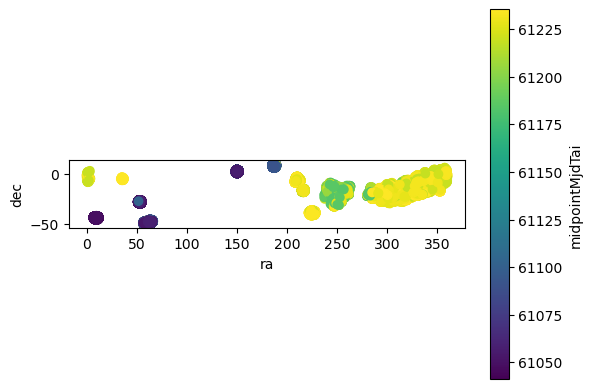

In [9]:
# scatter plot showing distribution of ra, dec of alerts across the sky
# NB this is just a quick cartesian plot, not a proper spherical sky projection
x_plot = "ra"
y_plot = "dec"
c_plot = "midpointMjdTai"
df_plot = df_dia
print(len(df_plot))

fig = plt.figure()
gs = gridspec.GridSpec(1, 1)
ax1 = plt.subplot(gs[0,0])

s1 = ax1.scatter(df_plot[x_plot], df_plot[y_plot],c = df_plot[c_plot])
cbar = plt.colorbar(s1)

ax1.set_xlabel(x_plot)
ax1.set_ylabel(y_plot)
cbar.set_label(c_plot)
ax1.set_aspect("equal")

plt.show()

In [10]:
# run this cell to make plots interactive
%matplotlib widget

In [11]:
# run this cell to make plots inline
%matplotlib inline

620481


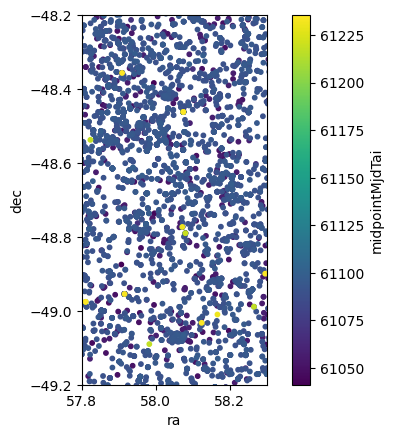

In [12]:
# zoom around interactively and look for lines of detections?
# e.g. ra ~ 58.1, dec ~ -48.7

x_plot = "ra"
y_plot = "dec"
c_plot = "midpointMjdTai"
df_plot = df_dia.sort_values(c_plot)
print(len(df_plot))

fig = plt.figure()
gs = gridspec.GridSpec(1, 1)
ax1 = plt.subplot(gs[0,0])

s1 = ax1.scatter(df_plot[x_plot], df_plot[y_plot],c = df_plot[c_plot], s=10)
cbar = plt.colorbar(s1)

ax1.set_xlabel(x_plot)
ax1.set_ylabel(y_plot)
cbar.set_label(c_plot)
ax1.set_aspect("equal")

ax1.set_xlim(57.8,58.3)
ax1.set_ylim(-49.2,-48.2)

plt.show()

In [13]:
# Isolate detections associated with the linear looking feature
# I used masks and histograms to narrow down detections based on ra, dec, trailAngle and visit

In [14]:
ra_mask = (df_dia['ra']<58.3) & (df_dia['ra']>57.8)
dec_mask = (df_dia['dec']<-48.) & (df_dia['dec']>-49.2)
ang_mask = (df_dia['trailAngle'] > 163) & (df_dia['trailAngle'] < 168)
visit_mask = df_dia['visit'] == 2026022300129

dia_mask = (ra_mask & dec_mask) & ang_mask & visit_mask
df_dia[dia_mask]

,diaSourceId,midpointMjdTai,ra,dec,trailFlux,trailLength,trailFluxErr,trailAngle,trailAngleErr,raErr,decErr,trailLengthErr,visit,detector,band,trailMag,trailMagErr
6183,170050485745614916,61095.089168,58.048986,-48.599615,10257.987305,4.477960,10.607827,165.169968,NaN,0.000020,0.000044,NaN,2026022300129,152,r,21.372345,0.001123
37171,170050485762916376,61095.089168,57.906336,-48.228835,10145.106445,3.554662,20.639898,164.469269,NaN,0.000018,0.000039,NaN,2026022300129,185,r,21.384357,0.002209
41705,170050485744042022,61095.089168,58.159826,-48.885803,9713.541992,4.346047,33.993286,164.676865,NaN,0.000022,0.000046,NaN,2026022300129,149,r,21.431557,0.003800
61854,170050485742469236,61095.089168,58.201726,-48.993421,9036.918945,3.180958,18.969568,164.750046,NaN,0.000012,0.000023,NaN,2026022300129,146,r,21.509951,0.002279
77336,170050485745614864,61095.089168,58.085914,-48.695157,9987.400391,4.328004,19.487463,166.819458,NaN,0.000020,0.000044,NaN,2026022300129,152,r,21.401369,0.002118
84798,170050485761343660,61095.089168,57.931896,-48.295482,4278.155762,3.454700,84.838463,164.464371,NaN,0.000046,0.000092,NaN,2026022300129,182,r,22.321857,0.021531
107511,170050485762916384,61095.089168,57.901587,-48.216304,11470.388672,4.350633,14.893858,166.500580,NaN,0.000018,0.000040,NaN,2026022300129,185,r,21.251053,0.001410
130853,170050485761343564,61095.089168,57.980036,-48.420710,10192.715820,3.655030,3.584125,167.056915,NaN,0.000021,0.000044,NaN,2026022300129,182,r,21.379276,0.000382
137355,170050485744042003,61095.089168,58.171303,-48.915335,11129.012695,4.328912,43.840698,165.688675,NaN,0.000020,0.000043,NaN,2026022300129,149,r,21.283857,0.004277
149058,170050485742469180,61095.089168,58.227443,-49.059303,3825.726318,3.319532,10.740926,163.265320,NaN,0.000046,0.000096,NaN,2026022300129,146,r,22.443216,0.003048


39


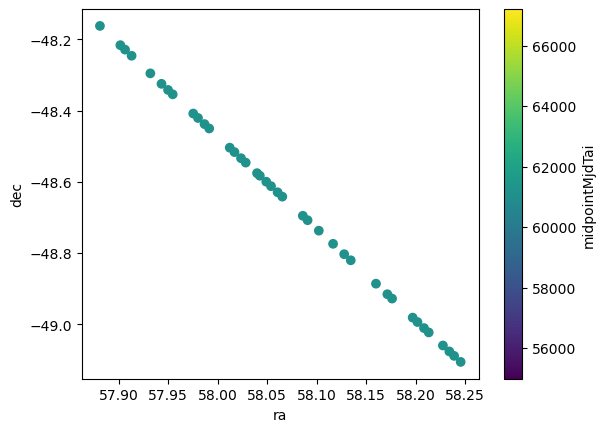

In [15]:
x_plot = "ra"
y_plot = "dec"
c_plot = "midpointMjdTai"

df_plot = df_dia[dia_mask].sort_values(c_plot)
print(len(df_plot))

fig = plt.figure()
gs = gridspec.GridSpec(1, 1)
ax1 = plt.subplot(gs[0,0])

s1 = ax1.scatter(df_plot[x_plot], df_plot[y_plot],c = df_plot[c_plot])
cbar = plt.colorbar(s1)

ax1.set_xlabel(x_plot)
ax1.set_ylabel(y_plot)
cbar.set_label(c_plot)

plt.show()


## Alert Cutout Images
Use the alert diaSourceIds to query Fink for more alert data, e.g. the cutout images

In [16]:
dia = np.array(df_dia[dia_mask]['diaSourceId'])
dia

array([170050485745614916, 170050485762916376, 170050485744042022,
       170050485742469236, 170050485745614864, 170050485761343660,
       170050485762916384, 170050485761343564, 170050485744042003,
       170050485742469180, 170050485742469221, 170050485761343621,
       170050485744042072, 170050485744042083, 170050485744042134,
       170050485745614855, 170050485742469148, 170050485761343636,
       170050485745614980, 170050485745614907, 170050485745614929,
       170050485745614997, 170050485742469169, 170050485745614898,
       170050485761343608, 170050485742469228, 170050485744042104,
       170050485745614891, 170050485745614924, 170050485762916362,
       170050485762916408, 170050485745614950, 170050485742469160,
       170050485761343543, 170050485761343576, 170050485745614957,
       170050485742469244, 170050485761343530, 170050485744041995])

In [17]:
save_dir = "cutouts_wcs"
if not os.path.isdir(save_dir):
    os.mkdir(save_dir)

In [18]:
# Use the fink api to query fits cutout images for each alert: https://doc.lsst.fink-broker.org/services/api/imagesearch/
for i,diaId in enumerate(dia):

    diaId = str(diaId)
    fname_fits = '{}/{}.fits'.format(save_dir,diaId)
    print("query {} cutout".format(diaId))

    r = requests.post(
        "https://api.lsst.fink-portal.org/api/v1/cutouts",
        json={
            "diaSourceId": diaId,
            "kind": "Science",
            "output-format": "FITS",
        },
    )
    

    hdu = fits.open(io.BytesIO(r.content), ignore_missing_simple=True)
    # hdu.writeto(fname_fits,overwrite='True') # save fits file without correcting the wcs


    # add missing/updated WCS fields to the PRIMARY header, keeping all other fields as well
    data = hdu["PRIMARY"].data
    hdr = hdu["PRIMARY"].header
    wcs = WCS(hdr)
    wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"] # updating the wcs ctype will also fix some other keys
    hdr_wcs = wcs.to_header()

    # add new keys that are missing from the original header (or update ones that have changed)
    for x in list(hdr_wcs.keys()):
        if x not in hdr:
            # print("add {}".format(x))
            hdr[x] = (hdr_wcs[x],hdr_wcs.comments[x])
        else:
            if hdr_wcs[x] != hdr[x]:
                # print("update {}".format(x))
                hdr[x] = (hdr_wcs[x],hdr_wcs.comments[x])
    

    # update the hdu header and save to file
    hdu["PRIMARY"] = fits.PrimaryHDU(data,header=hdr)
    hdu.writeto(fname_fits,overwrite='True',output_verify='ignore') # NB need to ignore verification 

query 170050485745614916 cutout
query 170050485762916376 cutout
query 170050485744042022 cutout
query 170050485742469236 cutout
query 170050485745614864 cutout


    Header size is not multiple of 2880: 157
There may be extra bytes after the last HDU or the file is corrupted. [astropy.io.fits.hdu.hdulist]


OSError: Empty or corrupt FITS file

## Inspect the fits images

In [ ]:
wcs_files = glob.glob("{}/*.fits".format(save_dir))
wcs_files = np.sort(wcs_files)
wcs_files

In [ ]:
# inspect one of the cutouts
hdu = fits.open(wcs_files[0])
hdu.info()

In [ ]:
# inspect the header
hdu["PRIMARY"].header

In [ ]:
# check the WCS
WCS(hdu["PRIMARY"].header)

In [ ]:
# plot the fits image with WCS projection
# NB that North is probably not up as expected due to LSSTCam rotation
hdu = fits.open(wcs_files[0])["PRIMARY"]
plot_img = hdu.data
plot_wcs = WCS(hdu.header)

fig = plt.figure()
gs = gridspec.GridSpec(1, 1)
ax1 = plt.subplot(gs[0,0], projection = plot_wcs)

# plot image with normalisation
norm = aviz.ImageNormalize(plot_img,interval=aviz.ZScaleInterval())
s1 = ax1.imshow(plot_img, norm=norm)
plt.colorbar(s1)

ax1.grid(color='white', ls='solid')

plt.show()


In [ ]:
# reproject the fits image to get North up

wcs_out, shape_out = find_optimal_celestial_wcs([hdu], hdu_in = "PRIMARY")

array, footprint = reproject_exact(input_data = hdu,
                                       hdu_in = "PRIMARY",
                                       output_projection = wcs_out, shape_out=shape_out,
                                   )


In [ ]:
wcs_out, shape_out

In [ ]:
plot_img = array
plot_wcs = wcs_out

fig = plt.figure()
gs = gridspec.GridSpec(1, 1)
ax1 = plt.subplot(gs[0,0], projection = plot_wcs)

# plot image
norm = aviz.ImageNormalize(plot_img,interval=aviz.ZScaleInterval())
s1 = ax1.imshow(plot_img, norm=norm)
plt.colorbar(s1)

ax1.grid(color='white', ls='solid')

plt.show()


## Plot all cutouts together

In [ ]:
# reproject and mosaic all cutouts to get them on a common projection

hdus =  [fits.open(f) for f in wcs_files][:10]

wcs_out, shape_out = find_optimal_celestial_wcs(hdus, hdu_in = "PRIMARY")

array, footprint = reproject_and_coadd(input_data = hdus,
                                       hdu_in = "PRIMARY",
                                       output_projection = wcs_out, shape_out=shape_out,
                                       reproject_function=reproject_adaptive,
                                       # boundary_mode = 'constant',
                                        # boundary_fill_value=np.nan,
                                      )

# TODO: reproject_adpative should allow setting of non image pixels to nan (e.g. boundary_mode, boundary_fill_value) but I can't figure it out right now...
# Set non image pixels to nan so that only cutout pixels show up in mosaic
array[array == 0] = np.nan
array

In [ ]:
wcs_out,shape_out

In [ ]:
# get the centre coordinates of each cutout
ra = []
dec = []
for i in range(len(hdus)):
    ra.append(hdus[i]["PRIMARY"].header['CRVAL1'])
    dec.append(hdus[i]["PRIMARY"].header['CRVAL2'])
ra = np.array(ra)
dec = np.array(dec)


In [ ]:
%matplotlib widget

In [ ]:
%matplotlib inline

In [ ]:
# plot all cutouts combined into a single image
# zoom in and verify that the cutouts all have consistent trailAngle
# these detections are probably flashes from a rapidly rotating piece of space debris

plot_img = array
plot_wcs = wcs_out

fig = plt.figure()
gs = gridspec.GridSpec(1, 1)
ax1 = plt.subplot(gs[0,0], projection = plot_wcs)

# plot image
norm = aviz.ImageNormalize(plot_img,interval=aviz.ZScaleInterval())
s1 = ax1.imshow(plot_img, norm=norm)

# use marker to highlight cutout position
ax1.scatter(ra, dec, transform=ax1.get_transform('world'), 
            edgecolor = 'r', facecolor = 'none', s = 100)

# ax1.scatter(c_cent.ra,c_cent.dec, transform=ax1.get_transform('world'),
#           edgecolor = "r", facecolor = 'none', s =200)

plt.colorbar(s1)

plt.show()
